# Annual Heat Demand → Peak Heat Power Conversion
**Using BDEW Standard Load Profiles (demandlib)**

The geothermal borehole lookup table uses **peak heat power (kW)**.
But the parquet only has **annual heat demand (kWh/yr)**.

This notebook converts annual heat demand to peak power using BDEW heat load profiles
— the same method used by SESMG.

Approach:
1. Generate normalised BDEW heat profile (annual sum = 1)
2. Find the maximum hourly value in the profile — this is the peak fraction
3. Multiply annual demand by peak fraction → peak power in kW

**Two building classes used:**
- SFH/TH → `shlp_type = 'EFH'` (Einfamilienhaus)
- MFH/AB → `shlp_type = 'MFH'` (Mehrfamilienhaus)

**Building age class:** Use the most common one — we check
the `construction_year` column in the parquet to confirm which class dominates.

## Step 1 — Imports and Configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import demandlib.bdew as bdew

warnings.filterwarnings('ignore')

BASE_DIR   = os.getcwd()
FILE_M3B   = os.path.join(BASE_DIR, 'DEA_method3b_final.parquet')
OUTPUT_DIR = os.path.join(BASE_DIR, 'clustering_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Weather locations ─────────────────────────────────────────────────────
# Same two reference cities as the PV calculation
LOCATIONS = ['Essen', 'Bad Marienberg']

# ── Building age class lookup (BDEW) ─────────────────────────────────────
# 7 building age classes from demandlib
BUILDING_AGE_CLASS_LOOKUP = {
    2:  (0,    1918),
    3:  (1919, 1948),
    5:  (1949, 1978),   # ← expected most common in NRW
    7:  (1979, 1990),
    9:  (1991, 2000),
    10: (2001, 2008),
    11: (2009, 9999)
}

# Wind class — 1 = sheltered, typical urban NRW
WIND_CLASS = 1

print('Imports OK')
print(f'Building age classes: {list(BUILDING_AGE_CLASS_LOOKUP.keys())}')

Imports OK
Building age classes: [2, 3, 5, 7, 9, 10, 11]


## Step 2 — Check Most Common Building Age Class in NRW Dataset

Use the most common building age class.
We check the `construction_year` column in the parquet to find which BDEW class
contains the most buildings.

In [2]:
m3b = pd.read_parquet(FILE_M3B, columns=['id', 'size_class', 'construction_year',
                                          'heat_total_kwh'])
print(f'Buildings loaded: {len(m3b):,}')
print(f'\nConstruction year range: {m3b["construction_year"].min()} — {m3b["construction_year"].max()}')
print(f'Missing construction year: {m3b["construction_year"].isna().sum():,}')

# Assign BDEW age class to each building
def get_age_class(year):
    if pd.isna(year):
        return 5  # default to most common
    for cls, (y_min, y_max) in BUILDING_AGE_CLASS_LOOKUP.items():
        if y_min <= year <= y_max:
            return cls
    return 5

m3b['building_age_class'] = m3b['construction_year'].apply(get_age_class)

print('\nBuilding count per age class:')
age_counts = m3b['building_age_class'].value_counts().sort_index()
for cls, count in age_counts.items():
    yr_range = BUILDING_AGE_CLASS_LOOKUP[cls]
    pct = count / len(m3b) * 100
    marker = ' <- MOST COMMON' if count == age_counts.max() else ''
    print(f'  Class {cls:2d}  ({yr_range[0]}-{yr_range[1]}): {count:>10,}  ({pct:.1f}%){marker}')

most_common_class = age_counts.idxmax()
print(f'\nMost common building age class: {most_common_class}')
print(f'Year range: {BUILDING_AGE_CLASS_LOOKUP[most_common_class]}')

Buildings loaded: 4,133,323

Construction year range: 1859 — 2022
Missing construction year: 0

Building count per age class:
  Class  2  (0-1918):    169,301  (4.1%)
  Class  3  (1919-1948):    147,701  (3.6%)
  Class  5  (1949-1978):  3,462,513  (83.8%) <- MOST COMMON
  Class  7  (1979-1990):     69,782  (1.7%)
  Class  9  (1991-2000):    138,709  (3.4%)
  Class 10  (2001-2008):    128,713  (3.1%)
  Class 11  (2009-9999):     16,604  (0.4%)

Most common building age class: 5
Year range: (1949, 1978)


## Step 3 — Generate BDEW Heat Profiles

Generate normalised heat load profiles for both locations and both building types.
The profile is normalised to annual sum = 1, so the peak value directly gives
the fraction of annual demand that falls in the peak hour.

We use the most common building age class found in Step 2.

In [3]:
# Create a full year hourly index
year_index = pd.date_range('2019-01-01', periods=8760, freq='h')

# Temperature data — use typical German annual temperature profile
# Original code used weather_df temperature — we use a synthetic typical year
# Essen: mean ~10°C, cold winter ~-5°C, warm summer ~25°C
# This is a simple sinusoidal approximation for NRW
def make_temperature_profile(mean_temp, amplitude, index):
    hours = np.arange(len(index))
    # Annual cycle: coldest in January (hour 0), warmest in July (hour ~4380)
    temp = mean_temp - amplitude * np.cos(2 * np.pi * hours / 8760)
    # Add daily cycle ±3°C
    temp += 3 * np.sin(2 * np.pi * hours / 24)
    return pd.Series(temp, index=index, name='temperature')

temp_essen       = make_temperature_profile(mean_temp=10.5, amplitude=12, index=year_index)
temp_bm          = make_temperature_profile(mean_temp=9.5,  amplitude=13, index=year_index)

temperatures = {
    'Essen':          temp_essen,
    'Bad Marienberg': temp_bm
}

print('Temperature profiles generated:')
for loc, temp in temperatures.items():
    print(f'  {loc:<20}: min={temp.min():.1f}°C  mean={temp.mean():.1f}°C  max={temp.max():.1f}°C')

Temperature profiles generated:
  Essen               : min=-4.5°C  mean=10.5°C  max=25.5°C
  Bad Marienberg      : min=-6.5°C  mean=9.5°C  max=25.5°C


In [4]:
# Generate BDEW heat profiles
# shlp_type: EFH = single family, MFH = multi family
SHLP_TYPES = {'EFH': ['SFH', 'TH'], 'MFH': ['MFH', 'AB']}

# Use most common age class
AGE_CLASS = most_common_class
print(f'Using building age class: {AGE_CLASS}  '
      f'({BUILDING_AGE_CLASS_LOOKUP[AGE_CLASS][0]}-{BUILDING_AGE_CLASS_LOOKUP[AGE_CLASS][1]})')
print()

heat_profiles = {}
peak_fractions = {}

for location, temp in temperatures.items():
    heat_profiles[location] = {}
    peak_fractions[location] = {}
    for shlp_type in SHLP_TYPES.keys():
        profile = bdew.HeatBuilding(
            df_index=year_index,
            temperature=temp,
            shlp_type=shlp_type,
            wind_class=WIND_CLASS,
            annual_heat_demand=1,   # normalised to 1
            name=f'{location}_{shlp_type}',
            building_class=AGE_CLASS
        ).get_bdew_profile()

        heat_profiles[location][shlp_type] = profile
        peak_val = profile.max()
        peak_fractions[location][shlp_type] = peak_val

        print(f'  {location:<20} {shlp_type}: peak fraction = {peak_val:.6f}  '
              f'(= {peak_val*1000:.2f} Wh per Wh annual)')

Using building age class: 5  (1949-1978)

  Essen                EFH: peak fraction = 0.000348  (= 0.35 Wh per Wh annual)
  Essen                MFH: peak fraction = 0.000295  (= 0.29 Wh per Wh annual)
  Bad Marienberg       EFH: peak fraction = 0.000342  (= 0.34 Wh per Wh annual)
  Bad Marienberg       MFH: peak fraction = 0.000289  (= 0.29 Wh per Wh annual)


## Step 4 — Visualise the Heat Profiles

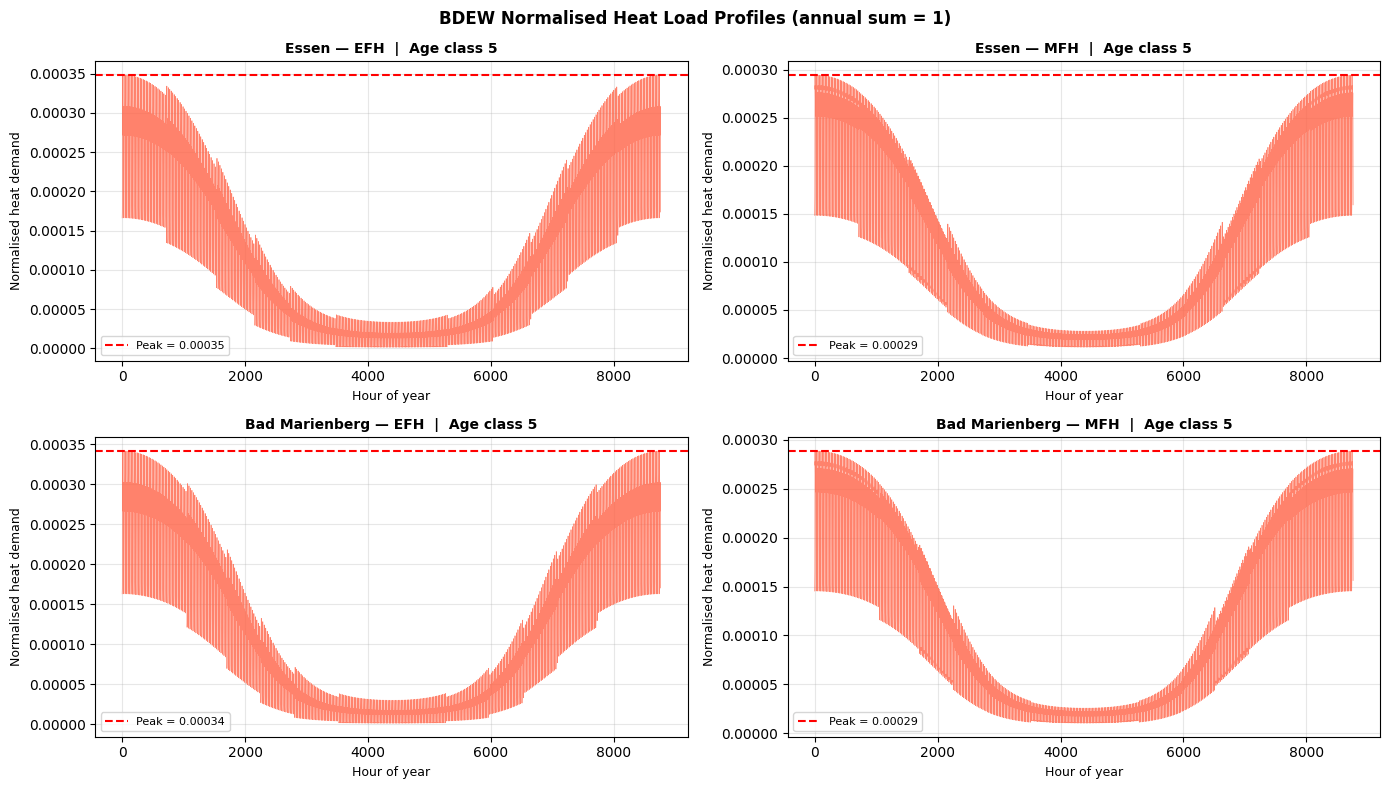

Profiles saved


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, location in enumerate(LOCATIONS):
    for col, shlp_type in enumerate(SHLP_TYPES.keys()):
        ax = axes[row][col]
        profile = heat_profiles[location][shlp_type]
        ax.plot(profile.values, lw=0.5, color='tomato', alpha=0.8)
        ax.axhline(y=profile.max(), color='red', ls='--', lw=1.5,
                   label=f'Peak = {profile.max():.5f}')
        ax.set_title(f'{location} — {shlp_type}  |  Age class {AGE_CLASS}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Hour of year', fontsize=9)
        ax.set_ylabel('Normalised heat demand', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('BDEW Normalised Heat Load Profiles (annual sum = 1)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'bdew_heat_profiles.pdf'), bbox_inches='tight')
plt.show()
print('Profiles saved')

## Step 5 — Convert Annual Demand to Peak Power

**Formula:**
```
peak_power_kw = (annual_heat_kwh × peak_fraction) × 1000 / 1
```

Where `peak_fraction` is the maximum hourly value from the normalised profile.
Since the profile is normalised to annual sum = 1, the peak fraction gives
the share of annual energy that falls in the single worst hour.

Multiplying annual demand (kWh) by this fraction gives the peak hour energy (kWh).
Since the timestep is 1 hour, peak energy (kWh) = peak power (kW).

In [6]:
# Map each building to its location and shlp_type
# Use nearest_city from parquet to assign location
m3b['shlp_type'] = m3b['size_class'].map(
    {'SFH': 'EFH', 'TH': 'EFH', 'MFH': 'MFH', 'AB': 'MFH'}
)

# Assign peak fraction based on location and building type
def get_peak_fraction(row):
    loc = row['nearest_city'] if 'nearest_city' in row.index else 'Essen'
    return peak_fractions.get(loc, peak_fractions['Essen'])[row['shlp_type']]

# Load nearest_city from parquet
m3b_full = pd.read_parquet(FILE_M3B, columns=[
    'id', 'size_class', 'construction_year', 'heat_total_kwh', 'nearest_city'
])
m3b_full['shlp_type']         = m3b_full['size_class'].map(
    {'SFH': 'EFH', 'TH': 'EFH', 'MFH': 'MFH', 'AB': 'MFH'})
m3b_full['building_age_class'] = m3b_full['construction_year'].apply(get_age_class)

# Apply peak fraction
m3b_full['peak_fraction'] = m3b_full.apply(
    lambda r: peak_fractions.get(r['nearest_city'],
              peak_fractions['Essen'])[r['shlp_type']], axis=1
)

# Peak power in kW
# heat_total_kwh × peak_fraction = peak hour energy in kWh = peak power in kW
m3b_full['peak_heat_power_kw'] = m3b_full['heat_total_kwh'] * m3b_full['peak_fraction']

print('Peak heat power calculated:')
print(f'  min  : {m3b_full["peak_heat_power_kw"].min():>10.1f} kW')
print(f'  mean : {m3b_full["peak_heat_power_kw"].mean():>10.1f} kW')
print(f'  max  : {m3b_full["peak_heat_power_kw"].max():>10.1f} kW')
print()
print('By size class:')
for sc in ['SFH', 'TH', 'MFH', 'AB']:
    sub = m3b_full[m3b_full['size_class'] == sc]
    print(f'  {sc}: mean={sub["peak_heat_power_kw"].mean():>8.1f} kW  '
          f'median={sub["peak_heat_power_kw"].median():>8.1f} kW  '
          f'max={sub["peak_heat_power_kw"].max():>8.1f} kW')

Peak heat power calculated:
  min  :        0.0 kW
  mean :       10.8 kW
  max  :     2960.6 kW

By size class:
  SFH: mean=    10.4 kW  median=     7.8 kW  max=  2960.6 kW
  TH: mean=     4.5 kW  median=     3.4 kW  max=   847.7 kW
  MFH: mean=    15.1 kW  median=    10.8 kW  max=  2953.2 kW
  AB: mean=    58.3 kW  median=    37.2 kW  max=  1005.0 kW


## Step 6 — Cross-check Against Lookup Table

For each building we now have `peak_heat_power_kw`.
Cross-check: look up required borehole area for each building using the lookup table.
This is a preview of what Task 4 (Boolean geothermal flag) will do.

In [7]:
# Load lookup table
lookup_path = os.path.join(OUTPUT_DIR, 'geothermal_lookup.csv')
if os.path.exists(lookup_path):
    lookup = pd.read_csv(lookup_path)
    print(f'Lookup table loaded: {len(lookup)} entries')

    # Match each building to nearest lookup entry
    def get_required_area(peak_kw, lookup_df):
        # Find closest heat power in lookup table
        idx = (lookup_df['heat_power_kw'] - peak_kw).abs().idxmin()
        return lookup_df.loc[idx, 'area_m2'], lookup_df.loc[idx, 'n_boreholes']

    # Apply to sample of 10,000 buildings for speed
    sample = m3b_full.sample(10_000, random_state=42).copy()
    results = sample['peak_heat_power_kw'].apply(
        lambda p: pd.Series(get_required_area(p, lookup),
                            index=['required_area_m2', 'n_boreholes'])
    )
    sample = pd.concat([sample, results], axis=1)

    print('\nRequired borehole area for sample of 10,000 buildings:')
    for sc in ['SFH', 'TH', 'MFH', 'AB']:
        sub = sample[sample['size_class'] == sc]
        if sub.empty: continue
        print(f'  {sc}: mean area={sub["required_area_m2"].mean():>8.1f} m²  '
              f'mean boreholes={sub["n_boreholes"].mean():>5.1f}  '
              f'n={len(sub):,}')
else:
    print('Lookup table not found — run geothermal_lookup_table.ipynb first')

Lookup table loaded: 23 entries

Required borehole area for sample of 10,000 buildings:
  SFH: mean area=    69.3 m²  mean boreholes=  2.0  n=6,618
  TH: mean area=    64.8 m²  mean boreholes=  1.1  n=1,165
  MFH: mean area=    85.2 m²  mean boreholes=  2.8  n=2,204
  AB: mean area=   285.5 m²  mean boreholes=  7.6  n=13


## Step 7 — Save Updated Parquet with Peak Power

In [8]:
# Save peak power column back to a new parquet
out_cols = ['id', 'size_class', 'heat_total_kwh',
            'peak_heat_power_kw', 'peak_fraction',
            'building_age_class', 'shlp_type']

out_path = os.path.join(OUTPUT_DIR, 'peak_heat_power.parquet')
m3b_full[out_cols].to_parquet(out_path, index=False)

print(f'Saved: {out_path}')
print(f'Rows: {len(m3b_full):,}')
print()
print('Next step — Task 4:')
print('  Once the lawn area dataset is available,')
print('  join it here and add:')
print('  geothermal_feasible = lawn_area_m2 >= required_area_m2')

Saved: c:\Users\zaito\Downloads\clustering_results\peak_heat_power.parquet
Rows: 4,133,323

Next step — Task 4:
  Once the lawn area dataset is available,
  join it here and add:
  geothermal_feasible = lawn_area_m2 >= required_area_m2
